# News Article Grouping Research

## Cross-Encoder Classifier EDA

For **Stage 2** of this research, we need to implement a model that, given two articles, can classify whether they refer to the **same event or not** (1 or 0).

The model we aim to develop is a fine-tuned version of **ModernBERT**, a transformer architecture designed for efficient long-context processing. Thanks to its extended context window of up to **8,192 tokens**, we can input both articles in the same sequence during comparison. This is a major advantage over many traditional models that are limited to **512 tokens**, which often forces aggressive truncation and can lead to information loss.

> *We will experiment with context lengths of **1024** and **2048 tokens** to evaluate which configuration performs better for our dataset.*

---

## Introduction

In this notebook, we perform **Exploratory Data Analysis (EDA)** on the **HLGD dataset**, which contains **20,056 labeled pairs of news articles**. By default, the dataset only includes the **headlines** of each article, but it also provides the **URLs** of the original sources.

Because of this, we conduct **two different experiments**:

1. **Headlines Only**  
   We use the dataset as provided, analyzing and training the model using only the **headline pairs**. This approach has the advantage of being immediately usable and computationally efficient. However, it also has an important limitation: headlines contain very limited context, which may cause the model to produce **false positives or false negatives** due to missing information about the full article.

2. **Headline + Content**  
   Using the provided URLs and web scraping techniques, we construct an extended dataset that includes both the **headline and the full article content**. This allows us to evaluate how the model performs when given **richer contextual information**, and whether access to the full text improves the model's ability to correctly determine if two articles describe the same event.

**Dataset reference:**  
[*Dataset Card for Headline Grouping (HLGD)*](https://huggingface.co/datasets/philippelaban/hlgd)

> **Important:** The original dataset splits had an imbalanced label distribution. To address this, we first concatenated the three splits and then generated new train/validation/test splits using the **stratify** parameter from `sklearn`, ensuring that the label distribution remains consistent across all subsets.

## Import Dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Headlines Only Analysis

For this part of the analysis, we use only the **headlines provided in the original dataset**, without incorporating the full article content.

### Load Datasets

The datasets contain the same underlying data as the original repository. However, the original splits had an uneven label distribution across the train, validation, and test sets.  

To address this, we **merged the original splits and generated new ones using stratified sampling**, ensuring that the label distribution remains consistent across all subsets.

In [82]:
headlines_train_df = pd.read_json(path_or_buf="/content/articles_pairs_train.json")
headlines_val_df = pd.read_json(path_or_buf="/content/articles_pairs_val.json")
headlines_test_df = pd.read_json(path_or_buf="/content/articles_pairs_test.json")

print(f"Headlines Only train dataset: {headlines_train_df.shape}")
print(f"Headlines Only validation dataset: {headlines_val_df.shape}")
print(f"Headlines Only test dataset: {headlines_test_df.shape}")

Headlines Only train dataset: (16044, 8)
Headlines Only validation dataset: (2006, 8)
Headlines Only test dataset: (2006, 8)


In [8]:
headlines_df = pd.concat(objs=[headlines_train_df,
                               headlines_val_df,
                               headlines_test_df])
print(f"Headlines Only dataset: {headlines_df.shape}")

Headlines Only dataset: (20056, 8)


### Labels Balance

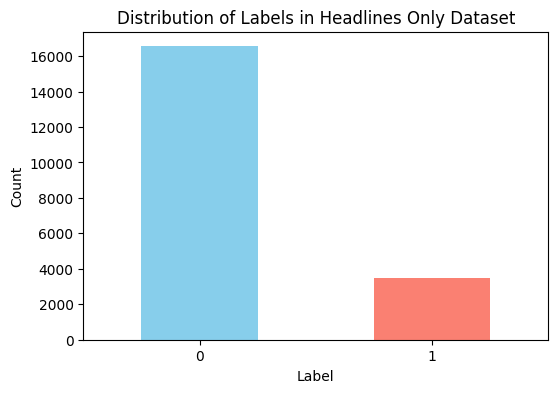

In [24]:
label_counts = headlines_df["label"].value_counts()

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribution of Labels in Headlines Only Dataset")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

We can clearly observe that the dataset presents a **class imbalance problem**. Out of the total samples, **16,550 pairs are labeled as negative** (the articles do **not** belong to the same event) and **3,506 pairs are labeled as positive** (the articles **do** belong to the same event). This corresponds to approximately **82.5% negative labels** and **17.5% positive labels**.

This imbalance must be taken into account during model training. The evaluation metrics and training strategy will differ from those used with balanced datasets, where **accuracy** can often be a reliable metric. In this case, we are particularly concerned with **True Positives** and **False Positives**, as the objective is to be as confident as possible when predicting that two articles belong to the same event.

Although **False Negatives** are still relevant, in the context of event grouping it is generally preferable for an article pair to be incorrectly classified as belonging to different events rather than mistakenly grouping two unrelated events together. In other words, **precision on positive predictions is especially important** for this task.

> *Note: Since the dataset is relatively small, we cannot afford to discard large portions of the data, unlike scenarios where millions of examples are available.*

### Analyzing Title Length

In this section, we analyze the length of the article headlines and their relationship with the pair label.

The goal is to determine whether headline length has any correlation with the likelihood that two articles belong to the same event. For example, we explore whether longer headlines are more frequently associated with article pairs that refer to the same event, or whether headline length has no meaningful relationship with the label.

In [37]:
headlines_df["headline_a_length"] = headlines_df["headline_a"].astype(str).str.count(r'\S+')
headlines_df["headline_b_length"] = headlines_df["headline_b"].astype(str).str.count(r'\S+')

print(f"Headlines A Description:\n{headlines_df["headline_a_length"].describe()}\n")
print(f"Headlines B Description:\n{headlines_df["headline_b_length"].describe()}\n")

Headlines A Description:
count    20056.000000
mean         9.839200
std          2.572939
min          3.000000
25%          8.000000
50%         10.000000
75%         11.000000
max         21.000000
Name: headline_a_length, dtype: float64

Headlines B Description:
count    20056.00000
mean         9.87495
std          2.53919
min          3.00000
25%          8.00000
50%         10.00000
75%         11.00000
max         21.00000
Name: headline_b_length, dtype: float64



We can observe that the mean, standard deviation, quantiles, and maximum values of the word counts for both headlines are approximately within the same range, and in some cases even identical.

In [ ]:
stats_by_label = headlines_df.groupby("label")[["headline_a_length", "headline_b_length"]].describe()
mean_by_label = headlines_df.groupby("label")[["headline_a_length", "headline_b_length"]].mean()

print(f"Stats by label:\n{stats_by_label}\n")
print(f"Mean by label:\n{stats_by_label}\n")

### Headline Length Statistics by Label

| Label | Headline | Count | Mean | Std | Min | 25% | Median | 75% | Max |
|------|----------|------|------|------|------|------|------|------|------|
| 0 | headline_a | 16,550 | 9.86 | 2.59 | 3 | 8 | 10 | 11 | 21 |
| 1 | headline_a | 3,506 | 9.76 | 2.47 | 4 | 8 | 10 | 11 | 21 |
| 0 | headline_b | 16,550 | 9.92 | 2.54 | 3 | 8 | 10 | 11 | 21 |
| 1 | headline_b | 3,506 | 9.68 | 2.53 | 4 | 8 | 9 | 11 | 21 |

<br/>

We analyzed the distribution of headline lengths for both `headline_a` and `headline_b` across the two labels.

The statistics show that the distributions are highly similar for both classes. For `headline_a`, the mean length is **9.86 words** for label `0` and **9.76 words** for label `1`. Similarly, for `headline_b`, the mean length is **9.92 words** for label `0` and **9.68 words** for label `1`. The medians are also nearly identical, with most headlines falling between **8 and 11 words** in both groups.

Additionally, the standard deviations are comparable (\~2.5 words), and the observed ranges are identical across labels (3-21 words). The interquartile ranges also overlap completely.

These results suggest that **headline length does not meaningfully differ between positive and negative labels**. Therefore, it is unlikely that headline length alone provides predictive signal for distinguishing between the two classes.

---

## 2. Headline + Content Analysis

To obtain the full content of the articles, we applied **web scraping techniques**. For this task, we used the `newspaper4k` library, which allows extracting the main content of news articles directly from their URLs. This tool was selected due to its **speed, simplicity, and out-of-the-box usability**. Additionally, it eliminates the need to manually analyze and implement custom scrapers for the structure of each of the ~40 news outlets present in the dataset.

> *In future experiments, we may implement more precise scraping pipelines that could potentially recover a larger portion of the missing articles.*

After the scraping process, we obtained **8,284 valid article pairs**, meaning that **11,832 pairs** did not pass the verification step. For a pair to be usable, **both articles needed to have successfully scraped content**. If one or both articles were missing their body text, the pair was discarded.

This data loss can be mainly attributed to two factors:
- **Outdated links:** Many of the articles are relatively old, and their original webpages are no longer available.
- **Paywalls:** Some outlets restrict access to their article content.

> *To partially mitigate the first issue, we attempted to retrieve archived versions using the Wayback Machine. While this approach helped recover some articles, it did not significantly increase the number of usable pairs.*

As a result, in addition to the **titles and metadata**, the dataset used in this section also includes the **full article content** for the remaining valid pairs.

### Load Datasets

In [49]:
full_train_df = pd.read_json(path_or_buf="/content/articles_pairs_content_train.json")
full_val_df = pd.read_json(path_or_buf="/content/articles_pairs_content_val.json")
full_test_df = pd.read_json(path_or_buf="/content/articles_pairs_content_test.json")

print(f"Headlines + Content train dataset: {full_train_df.shape}")
print(f"Headlines + Content validation dataset: {full_val_df.shape}")
print(f"Headlines + Content dataset: {full_test_df.shape}")

Headlines + Content train dataset: (6627, 12)
Headlines + Content validation dataset: (828, 12)
Headlines + Content dataset: (829, 12)


In [50]:
full_df = pd.concat(objs=[full_train_df,
                          full_val_df,
                          full_test_df])
print(f"Headlines + Content dataset: {full_df.shape}")

Headlines + Content dataset: (8284, 12)


### Labels Balance

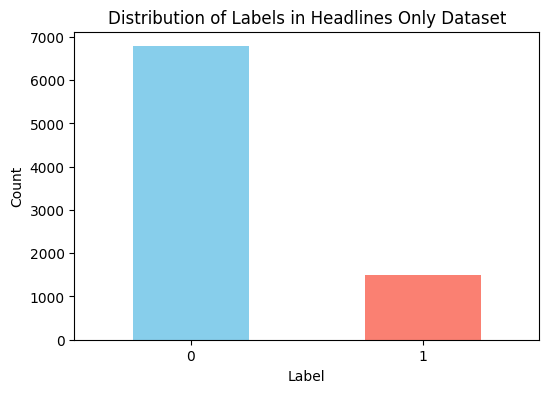

In [51]:
label_counts = full_df["label"].value_counts()

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribution of Labels in Headlines Only Dataset")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

For the dataset that includes the full article content, the class imbalance remains present at a similar proportion to the headline-only dataset. Specifically, the dataset contains **6,783 negative labels (\~82%)** and **1,501 positive labels (\~18%)**. This indicates that the dataset is strongly skewed toward the negative class.

### Analyzing Title Length

In this section, we analyze the length of the article headlines and their relationship with the pair label. Since the number of samples differs in this dataset, it is useful to re-evaluate this feature to determine whether any patterns or changes emerge compared to the previous analysis.

In [53]:
full_df["headline_a_length"] = full_df["headline_a"].astype(str).str.count(r'\S+')
full_df["headline_b_length"] = full_df["headline_b"].astype(str).str.count(r'\S+')

print(f"Headlines A Description:\n{full_df["headline_a_length"].describe()}\n")
print(f"Headlines B Description:\n{full_df["headline_b_length"].describe()}\n")

Headlines A Description:
count    8284.000000
mean        9.700145
std         2.855089
min         3.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        21.000000
Name: headline_a_length, dtype: float64

Headlines B Description:
count    8284.000000
mean        9.706543
std         2.741061
min         3.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        21.000000
Name: headline_b_length, dtype: float64



We can observe that the mean, standard deviation, quantiles, and maximum values of the word counts for both headlines are approximately within the same range, and in some cases even identical.

In [ ]:
stats_by_label = full_df.groupby("label")[["headline_a_length", "headline_b_length"]].describe()
mean_by_label = full_df.groupby("label")[["headline_a_length", "headline_b_length"]].mean()

print(f"Title stats by label:\n{stats_by_label}\n")
print(f"Title mean by label:\n{stats_by_label}\n")

### Title Length Statistics by Label

| Label | Headline | Count | Mean | Std | Min | 25% | Median | 75% | Max |
|------|----------|------|------|------|------|------|------|------|------|
| 0 | headline_a | 6,783 | 9.67 | 2.86 | 3 | 8 | 9 | 11 | 21 |
| 1 | headline_a | 1,501 | 9.82 | 2.85 | 4 | 8 | 9 | 11 | 21 |
| 0 | headline_b | 6,783 | 9.73 | 2.73 | 3 | 8 | 9 | 12 | 21 |
| 1 | headline_b | 1,501 | 9.61 | 2.81 | 4 | 8 | 9 | 11 | 21 |

The distributions of headline lengths for both `headline_a` and `headline_b` fall within very similar ranges across the two labels. The mean values differ only marginally, and the quartile ranges are nearly identical. Most headlines fall between **8 and 11 words**, with maximum lengths reaching **21 words** in both classes.

These results indicate that **headline length remains consistent across labels**, suggesting that this feature is unlikely to provide meaningful discriminatory signal between the positive and negative classes.

### Analyzing Content Length

In this section, we analyze the length of the article contents and their relationship with the pair label.

In [57]:
full_df["body_a_length"] = full_df["body_a"].astype(str).str.count(r'\S+')
full_df["body_b_length"] = full_df["body_b"].astype(str).str.count(r'\S+')

print(f"Bodys A Description:\n{full_df["body_a_length"].describe()}\n")
print(f"Bodys B Description:\n{full_df["body_b_length"].describe()}\n")

Bodys A Description:
count     8284.000000
mean       629.988653
std       1435.231586
min         14.000000
25%        204.000000
50%        468.000000
75%        709.000000
max      16109.000000
Name: body_a_length, dtype: float64

Bodys B Description:
count     8284.000000
mean       589.364679
std       1136.549850
min         14.000000
25%        251.750000
50%        482.000000
75%        708.000000
max      16109.000000
Name: body_b_length, dtype: float64



We can observe that most values fall within similar ranges across both labels. The only noticeable difference appears in the **standard deviation**, which is **1,425 for content A** and **1,136 for content B**, indicating slightly higher variability in the length of content A.

Apart from this difference, both the **minimum and maximum lengths are identical**. This is likely due to the dataset construction, where the same articles may appear in multiple pairs and are therefore compared against different articles. As a result, identical articles can contribute repeatedly to the observed minimum and maximum values.

In [ ]:
stats_by_label = full_df.groupby("label")[["body_a_length", "body_b_length"]].describe()
mean_by_label = full_df.groupby("label")[["body_a_length", "body_b_length"]].mean()

print(f"Content stats by label:\n{stats_by_label}\n")
print(f"Content mean by label:\n{stats_by_label}\n")

### Content Length Statistics by Label

| Label | Content | Count | Mean | Std | Min | 25% | Median | 75% | Max |
|------|---------|------|------|------|------|------|------|------|------|
| 0 | body_a | 6,783 | 605.95 | 1331.33 | 14 | 192 | 465 | 708 | 16,109 |
| 1 | body_a | 1,501 | 738.62 | 1829.35 | 16 | 248 | 491 | 709 | 16,109 |
| 0 | body_b | 6,783 | 587.55 | 1139.80 | 14 | 251 | 483 | 708 | 16,109 |
| 1 | body_b | 1,501 | 597.58 | 1122.10 | 14 | 262 | 481 | 703 | 16,109 |

Most of the statistics fall within similar ranges across the two labels. The **quartiles, medians, and minimum values** are very close for both `body_a` and `body_b`, indicating that the majority of article lengths are comparable regardless of the label.

The main difference appears in the **standard deviation**, which is noticeably larger for `body_a` in the positive class. This suggests greater variability in the lengths of articles within that group. However, the similarity in the quartile values indicates that the bulk of the data remains concentrated within a similar range, and the higher variability is likely driven by a small number of very long articles (i.e., outliers).

Overall, content length does not appear to differ substantially between labels for the majority of the dataset.

<br/>

Additionally, we observed that only **two unique articles exceed 3,500 words**, each containing approximately **16,000 words**. These articles represent clear **outliers** in the dataset and could potentially influence some descriptive statistics.

However, during preprocessing the articles will be **tokenized and truncated** to a maximum length of either **1,024 or 2,048 tokens**. As a result, these outliers will effectively be reduced to lengths comparable to the rest of the dataset during model training. This approach assumes that the most relevant information of the articles is contained within the retained portion after truncation.

Furthermore, a manual inspection of these two articles did not reveal any structural issues or malformed content. They appear to be valid articles, suggesting that their unusually large length is simply an artifact of the source rather than a data quality issue. Therefore, with truncation applied, they are unlikely to introduce significant problems in the experimental setup.

---

## Dataset Preparation

In this section, we prepare both datasets—the **Headlines Only** dataset and the **Headline + Content** dataset—so they are ready to be used in the model development notebook. This will allow us to train and evaluate models on both versions and compare their performance to determine which representation is more suitable for our task.

The final datasets will contain only the fields required for the classification task: the **label**, the **headline of article A**, and the **headline of article B**. In the case of the second dataset, the **content of both articles** will also be included.

Other attributes such as the **publication date** and **article URL** are removed. These fields are not directly relevant for the similarity classification task and could potentially introduce unwanted biases or shortcuts (e.g., learning patterns based on timing or source links rather than the article content itself).

In [83]:
headlines_train_df = headlines_train_df.drop(labels=["timeline_id", "date_a", "date_b", "url_a", "url_b"], axis=1)
headlines_val_df = headlines_val_df.drop(labels=["timeline_id", "date_a", "date_b", "url_a", "url_b"], axis=1)
headlines_test_df = headlines_test_df.drop(labels=["timeline_id", "date_a", "date_b", "url_a", "url_b"], axis=1)

print("Successully prepared headlines-only datasets")

Successully prepared headlines-only datasets


In [84]:
full_train_df = full_train_df.drop(labels=["timeline_id", "date_a", "date_b", "url_a", "url_b"], axis=1)
full_val_df = full_val_df.drop(labels=["timeline_id", "date_a", "date_b", "url_a", "url_b"], axis=1)
full_test_df = full_test_df.drop(labels=["timeline_id", "date_a", "date_b", "url_a", "url_b"], axis=1)

print("Successully prepared headline + content datasets")

Successully prepared headline + content datasets


### Saving Datasets

In [87]:
DEFAULT_PATH = "/content/processed"
files_to_save = [
    (f"{DEFAULT_PATH}/articles_pairs_train.csv", headlines_train_df),
    (f"{DEFAULT_PATH}/articles_pairs_val.csv", headlines_val_df),
    (f"{DEFAULT_PATH}/articles_pairs_test.csv", headlines_test_df),
    (f"{DEFAULT_PATH}/articles_pairs_content_train.csv", full_train_df),
    (f"{DEFAULT_PATH}/articles_pairs_content_val.csv", full_val_df),
    (f"{DEFAULT_PATH}/articles_pairs_content_test.csv", full_test_df),
]

for path, dataframe in files_to_save:
    dataframe.to_csv(path_or_buf=path,
                     index=False)

print("Sucessfully saved dataframes")

Sucessfully saved dataframes


In [94]:
from google.colab import files
files.download("/content/processed")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

After performing exploratory data analysis (EDA) on the article pair datasets, we found **no meaningful relationship between headline length and the assigned pair label**. A similar observation holds for the dataset that includes article content, where **content length also does not appear to be associated with the label**.

Additionally, both datasets exhibit a **significant class imbalance**, with an approximate **82/18 ratio between negative and positive labels**. This imbalance must be taken into consideration during model development, as it can affect training dynamics and lead to misleading evaluation results if inappropriate metrics are used.

In summary, we work with **two datasets**, each split into **training, validation, and test sets**:

1. **Title Only** – Contains only the pair of article headlines and the corresponding label.
2. **Title + Content** – Contains the headlines and full article contents for both articles in the pair, along with the corresponding label.